# EQNN-for-HEP, ported to TorchQuantum, on Gravitational-Lensing data

This notebook re-implements the **core idea of the `EQNN_for_HEP` repository**
(Equivariant Quantum Convolutional Neural Network, EQCNN) in **TorchQuantum**, and
trains it on the **DeepLense gravitational-lensing** dataset (3 classes: `axion`, `cdm`, `no_sub`).

## What is the EQNN-for-HEP core idea?

The original PennyLane repo (`Equivariant_QCNN`) builds a QCNN that is **equivariant under the
`p4m` image-symmetry group** (90 rotations + X/Y reflections). It has three symmetry-respecting
ingredients, all of which we reproduce here:

1. **Equivariant amplitude embedding** (`embedding.equivariant_amplitude_encoding`):
   a 16x16 image is mapped to a `2^8 = 256`-amplitude state on 8 qubits, with the
   antisymmetric pixel transform `sin(pi/2 * (2*p - 1))` and L2 normalization. This pixel map is
   what makes the encoding compatible with the reflection symmetry.
2. **Equivariant convolution filters** (`unitary.U2_equiv`, `unitary.U4_equiv`): built **only** from
   symmetry-commuting generators - single-qubit `RX`, pairwise `IsingZZ` / `IsingYY` (for `U2`), and a
   global `Z^{otimes 4}` diagonal phase (for `U4`). With **tied parameters** across each orbit of wires
   the layer commutes with the group representation.
3. **Equivariant pooling + invariant measurement** (`unitary.Pooling_ansatz_equiv`,
   `QCNN_circuit.p4m_QCNN_structure`): the conv/pool connectivity respects the `p4m` orbits and the
   readout is taken on the centre qubit (after a final `Hadamard`), giving an **invariant** output.

## How we adapt it to lensing images

The HEP repo consumes `16x16x1` HEP calorimeter images. The DeepLense `.npy` images are `150x150`,
so we keep the dataset class from `fully_equivariant_p4m_qcnn_v2/model_1.ipynb` **unchanged** and add a
tiny **symmetry-friendly classical reducer** (adaptive average pool to `16x16`) so the exact
256-amplitude equivariant encoding from the paper applies directly. Average pooling commutes with the
D4 image symmetries, so it does not break the equivariance argument.

> Faithful port: the quantum block (embedding + `U2`/`U4` filters + equivariant pooling) is a direct
> TorchQuantum translation of `EQNN_for_HEP/Equivariant_QCNN`, only the data front-end is new.

In [1]:
import os
import time
import copy
import json
from pathlib import Path
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchquantum as tq

import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report, f1_score
from sklearn.preprocessing import label_binarize

torch.manual_seed(42)
np.random.seed(42)
os.environ["OMP_NUM_THREADS"] = "1"

print(f"TorchQuantum version: {tq.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

TorchQuantum version: 0.1.8
PyTorch version: 2.5.1+cu124
CUDA available: True


## 0. Config

8 qubits (as in the HEP repo), `16x16` reduced images for the 256-amplitude equivariant encoding,
and the DeepLense 3-class lensing dataset paths.

In [2]:
# ---- Quantum / encoding config (matches EQNN_for_HEP) ----
N_QUBITS = 8                 # 8 qubits -> 2^8 = 256 amplitudes = 16x16 image
ENC_SIZE = 16                # images are reduced to 16x16 before equivariant encoding

# ---- Training ----
step = 1e-3
weight_decay = 1e-5
batch_size = 64
num_epochs = 50
patience = 12

# ---- Data ----
in_channels = 1
num_classes = 3

NOTEBOOK_NAME = "eqnn_hep_torchquantum"
DATASET_ID = os.environ.get("DEEPLENSE_DATASET_ID", "model_1")

def slugify(value):
    value = str(value).strip().lower()
    slug = "".join(ch if ch.isalnum() else "_" for ch in value)
    return "_".join(part for part in slug.split("_") if part) or "model_1"

DATASET_ID = slugify(DATASET_ID)
VALID_DATASET_IDS = {f"model_{i}" for i in range(1, 5)}
if DATASET_ID not in VALID_DATASET_IDS:
    raise ValueError(f"DATASET_ID must be one of {sorted(VALID_DATASET_IDS)}, got {DATASET_ID!r}")

# Same dataset layout used by fully_equivariant_p4m_qcnn_v2/model_1.ipynb
DATASET_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV",
}
TEST_ROOTS = {
    "model_1": "/home/jovyan/ssh-test-datavol-1/dataset/Model_I_test",
    "model_2": "/home/jovyan/ssh-test-datavol-1/dataset/Model_II_test",
    "model_3": "/home/jovyan/ssh-test-datavol-1/dataset/Model_III_test",
    "model_4": "/home/jovyan/ssh-test-datavol-1/dataset/Model_IV_test",
}
DATA_ROOT = os.environ.get("DEEPLENSE_DATA_ROOT", DATASET_ROOTS[DATASET_ID])
TEST_DIR = os.environ.get("DEEPLENSE_TEST_DIR", TEST_ROOTS[DATASET_ID])
VAL_SPLIT = float(os.environ.get("DEEPLENSE_VAL_SPLIT", "0.20"))

CACHE_DATA_IN_MEMORY = os.environ.get("DEEPLENSE_CACHE_DATA", "1") != "0"
NUM_WORKERS = int(os.environ.get("DEEPLENSE_NUM_WORKERS", str(min(4, os.cpu_count() or 0))))
PREFETCH_FACTOR = int(os.environ.get("DEEPLENSE_PREFETCH_FACTOR", "4"))
PIN_MEMORY = torch.cuda.is_available()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

RUN_DIR = Path.cwd() / DATASET_ID
RESULTS_DIR = RUN_DIR / "results"
CHECKPOINT_DIR = RUN_DIR / "checkpoints"
CHECKPOINT_PATH = CHECKPOINT_DIR / f"best_{NOTEBOOK_NAME}_{DATASET_ID}.pth"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"TEST_DIR:  {TEST_DIR}")
print(f"Qubits: {N_QUBITS} | encoding image: {ENC_SIZE}x{ENC_SIZE} | classes: {num_classes}")
print(f"Device: {device}")

DATA_ROOT: /home/jovyan/ssh-test-datavol-1/dataset/Model_I
TEST_DIR:  /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test
Qubits: 8 | encoding image: 16x16 | classes: 3
Device: cuda:0


## 1. Dataset (kept from `fully_equivariant_p4m_qcnn_v2/model_1.ipynb`)

This is the **same `.npy` lensing dataset class** you pointed me at - unchanged. It loads `.npy`
images organized in class folders, normalizes them, optionally caches them in RAM, resizes via a
transform, and builds a stratified train/val split.

In [3]:
import collections

IMAGE_KEYS = ("image", "img", "x", "data", "array", "arr", "lens", "sample")


def extract_image_array(value):
    """Return the image array from raw .npy content, including object arrays."""
    if isinstance(value, np.ndarray):
        if value.dtype == object:
            if value.ndim == 0:
                return extract_image_array(value.item())
            for item in value.reshape(-1):
                try:
                    candidate = extract_image_array(item)
                    if np.asarray(candidate).ndim >= 2:
                        return candidate
                except Exception:
                    continue
            return np.asarray(value.tolist())
        return value

    if isinstance(value, dict):
        for key in IMAGE_KEYS:
            if key in value:
                return extract_image_array(value[key])
        for item in value.values():
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        raise ValueError("Could not find an image-like array in .npy dict")

    if isinstance(value, (list, tuple)):
        for item in value:
            try:
                candidate = extract_image_array(item)
                if np.asarray(candidate).ndim >= 2:
                    return candidate
            except Exception:
                continue
        return np.asarray(value)

    return np.asarray(value)


def load_npy_image(filepath):
    raw = np.load(filepath, allow_pickle=True)
    arr = np.asarray(extract_image_array(raw))
    if arr.dtype == object:
        arr = np.asarray(extract_image_array(arr), dtype=np.float32)
    else:
        arr = arr.astype(np.float32, copy=False)

    arr = np.squeeze(arr)
    if arr.ndim == 2:
        arr = arr[np.newaxis, :, :]
    elif arr.ndim == 3:
        if arr.shape[0] not in (1, 3):
            arr = arr.transpose(2, 0, 1)
    else:
        raise ValueError(f"Expected a 2D or 3D image array from {filepath}, got shape {arr.shape}")

    if arr.size == 0:
        raise ValueError(f"Empty image array in {filepath}")

    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    arr_max = float(np.max(arr))
    if arr_max > 1.0:
        arr = arr / arr_max
    return arr.astype(np.float32, copy=False)


class NPYImageFolder(Dataset):
    """Dataset loader for .npy image files organized in class folders."""

    def __init__(self, root_dir, transform=None, samples=None, classes=None, class_to_idx=None, cache=False):
        self.root_dir = str(root_dir)
        self.transform = transform
        self.cache = None
        if not os.path.isdir(self.root_dir):
            raise FileNotFoundError(f"Dataset directory not found: {self.root_dir}")

        self.classes = list(classes) if classes is not None else sorted(
            d for d in os.listdir(self.root_dir)
            if os.path.isdir(os.path.join(self.root_dir, d))
        )
        self.class_to_idx = dict(class_to_idx) if class_to_idx is not None else {
            cls: idx for idx, cls in enumerate(self.classes)
        }

        if samples is None:
            self.samples = []
            for class_name in self.classes:
                class_dir = os.path.join(self.root_dir, class_name)
                for filename in sorted(os.listdir(class_dir)):
                    if filename.endswith(".npy"):
                        filepath = os.path.join(class_dir, filename)
                        self.samples.append((filepath, self.class_to_idx[class_name]))
        else:
            self.samples = list(samples)

        if not self.samples:
            raise RuntimeError(f"No .npy files found under {self.root_dir}")

        self.labels = torch.tensor([label for _, label in self.samples], dtype=torch.long)

        print(f"Found {len(self.samples)} samples in {self.root_dir}")
        print(f"Classes: {self.classes}")

        if cache:
            desc = f"cache {Path(self.root_dir).name}"
            print(f"Caching {len(self.samples)} decoded samples from {self.root_dir} in RAM...")
            self.cache = [
                torch.from_numpy(np.ascontiguousarray(load_npy_image(filepath))).float()
                for filepath, _ in tqdm(self.samples, desc=desc, leave=False)
            ]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, label = self.samples[idx]
        if self.cache is None:
            arr = load_npy_image(filepath)
            tensor = torch.from_numpy(np.ascontiguousarray(arr)).float()
        else:
            tensor = self.cache[idx]

        if self.transform:
            tensor = self.transform(tensor)

        return tensor, label


class NPYTransform:
    """Resize and channel-match NPY tensors."""

    def __init__(self, img_size, in_channels=1):
        self.img_size = img_size
        self.in_channels = in_channels

    def __call__(self, x):
        if x.shape[0] == 1 and self.in_channels == 3:
            x = x.repeat(3, 1, 1)
        elif x.shape[0] == 3 and self.in_channels == 1:
            x = x.mean(dim=0, keepdim=True)
        elif x.shape[0] != self.in_channels:
            x = x[:self.in_channels]

        if x.shape[-1] != self.img_size or x.shape[-2] != self.img_size:
            x = F.interpolate(
                x.unsqueeze(0), size=(self.img_size, self.img_size),
                mode="bilinear", align_corners=False,
            ).squeeze(0)
        return x


def stratified_train_val_samples(samples, val_split=0.20, seed=42):
    """Split a single class-folder dataset into train/val while preserving each class."""
    labels = np.array([label for _, label in samples])
    rng = np.random.default_rng(seed)
    train_indices, val_indices = [], []
    for class_id in sorted(np.unique(labels).tolist()):
        class_indices = np.where(labels == class_id)[0]
        rng.shuffle(class_indices)
        if len(class_indices) <= 1:
            n_val = 0
        else:
            n_val = max(1, int(round(len(class_indices) * val_split)))
            n_val = min(n_val, len(class_indices) - 1)
        val_indices.extend(class_indices[:n_val].tolist())
        train_indices.extend(class_indices[n_val:].tolist())
    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    train_samples = [samples[i] for i in train_indices]
    val_samples = [samples[i] for i in val_indices]
    if not train_samples or not val_samples:
        raise ValueError("Train/val split is empty. Check VAL_SPLIT and per-class sample counts.")
    return train_samples, val_samples


def make_dataloader(dataset, batch_size, shuffle):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = PREFETCH_FACTOR
    return DataLoader(dataset, **kwargs)


def build_loaders(data_root, test_dir, img_size, batch_size, in_channels, val_split=0.20, seed=42):
    t0 = time.time()
    transform = NPYTransform(img_size, in_channels=in_channels)
    cache_data = CACHE_DATA_IN_MEMORY

    full_dataset = NPYImageFolder(data_root, transform=None, cache=False)
    train_samples, val_samples = stratified_train_val_samples(
        full_dataset.samples, val_split=val_split, seed=seed
    )
    train_set = NPYImageFolder(
        data_root, transform, samples=train_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx, cache=cache_data,
    )
    val_set = NPYImageFolder(
        data_root, transform, samples=val_samples,
        classes=full_dataset.classes, class_to_idx=full_dataset.class_to_idx, cache=cache_data,
    )
    test_set = NPYImageFolder(test_dir, transform, cache=cache_data)

    if test_set.classes != full_dataset.classes:
        raise ValueError(
            f"Class folders differ between DATA_ROOT and TEST_DIR: "
            f"{full_dataset.classes} vs {test_set.classes}"
        )

    train_loader = make_dataloader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = make_dataloader(val_set, batch_size=batch_size, shuffle=False)
    test_loader = make_dataloader(test_set, batch_size=batch_size, shuffle=False)

    counts = collections.Counter(train_set.labels.tolist())
    print(f"Loader build took {time.time() - t0:.1f}s")
    print(f"Sizes: train={len(train_set)} val={len(val_set)} test={len(test_set)}")
    print("Class counts (train):", {full_dataset.classes[k]: v for k, v in sorted(counts.items())})
    return train_loader, val_loader, test_loader, full_dataset.classes


# Keep the lensing images at a modest resolution; the quantum reducer pools them to 16x16.
LOAD_IMG_SIZE = 64
train_loader, val_loader, test_loader, class_names = build_loaders(
    DATA_ROOT, TEST_DIR, img_size=LOAD_IMG_SIZE, batch_size=batch_size,
    in_channels=in_channels, val_split=VAL_SPLIT,
)
print("Classes:", class_names)

Found 87525 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Found 70021 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Caching 70021 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I in RAM...


Found 17504 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I
Classes: ['axion', 'cdm', 'no_sub']
Caching 17504 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I in RAM...


Found 15000 samples in /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test
Classes: ['axion', 'cdm', 'no_sub']
Caching 15000 decoded samples from /home/jovyan/ssh-test-datavol-1/dataset/Model_I_test in RAM...


Loader build took 316.2s
Sizes: train=70021 val=17504 test=15000
Class counts (train): {'axion': 23118, 'cdm': 23818, 'no_sub': 23085}
Classes: ['axion', 'cdm', 'no_sub']


## 2. Amplitude embedding (HEP port + variance-preserving fix)

The original `equivariant_amplitude_encoding` uses the antisymmetric pixel map `sin(pi/2*(2p-1))`,
L2-normalized, loaded as the 256 **amplitudes** of the 8-qubit state.

On faint 3-class lensing maps that map is **signal-destroying**: backgrounds `p~0` go to `sin(-pi/2) = -1`,
so after L2 normalization every image looks nearly identical and the single-qubit readouts collapse to
`<Z> ~ 0` with ~0 variance across the batch -> the model sticks at `loss = ln(3)` (chance).

Fix (per the chosen approach): **per-sample contrast normalization** of the 16x16 image *before* the
pixel map, which restores variance across samples while keeping the antisymmetric, D4-compatible map.
We keep `raw_amplitude_features` (the exact repo map) available for reference / ablation.

In [4]:
def raw_amplitude_features(imgs16: torch.Tensor) -> torch.Tensor:
    """Exact EQNN_for_HEP map (kept for ablation): sin(pi/2*(2p-1)), L2-normalized."""
    b = imgs16.shape[0]
    feats = torch.sin(np.pi / 2.0 * (2.0 * imgs16 - 1.0))
    feats = feats.reshape(b, -1)
    norm = torch.linalg.norm(feats, dim=1, keepdim=True).clamp_min(1e-12)
    return feats / norm


def equivariant_amplitude_features(imgs16: torch.Tensor) -> torch.Tensor:
    """Variance-preserving amplitude features for faint lensing data.

    imgs16: (B, 16, 16) in [0, 1]. returns: (B, 256) real amplitudes, L2-normalized per sample.

    Steps (all elementwise/per-sample -> still commute with D4 pixel permutations):
      1. per-sample standardization (zero mean, unit std) to expose the faint signal,
      2. antisymmetric squashing map tanh (keeps the sign structure of the repo's sin map),
      3. L2 normalization to form a valid statevector.
    Row-major flatten of the 16x16 grid == index 2**n*i + j (n=4), matching the repo layout.
    """
    b = imgs16.shape[0]
    x = imgs16.reshape(b, -1)                                   # (B, 256)
    mean = x.mean(dim=1, keepdim=True)
    std = x.std(dim=1, keepdim=True).clamp_min(1e-6)
    x = (x - mean) / std                                        # per-sample contrast normalization
    feats = torch.tanh(x)                                       # antisymmetric, D4-compatible
    norm = torch.linalg.norm(feats, dim=1, keepdim=True).clamp_min(1e-12)
    return feats / norm


def amplitude_encode(qdev: tq.QuantumDevice, features: torch.Tensor) -> None:
    """Load real amplitudes (B, 2**n_wires) into the quantum device state (like AmplitudeEmbedding)."""
    bsz, dim = features.shape
    n_wires = qdev.n_wires
    assert dim == 2 ** n_wires, f"expected {2 ** n_wires} amplitudes, got {dim}"
    # reset_states ensures device bsz matches the current batch (recommended for varying batch sizes)
    qdev.reset_states(bsz)
    states = features.to(torch.complex64).reshape([bsz] + [2] * n_wires)
    qdev.set_states(states)

## 3. Equivariant gates (TorchQuantum port of `unitary.py`)

`IsingZZ`/`IsingYY` are not primitive single calls in this TorchQuantum build, so we decompose them
with the standard `CNOT - RZ - CNOT` (and `RX` basis change for `YY`) identities. Both are
**SWAP-symmetric**, exactly as required by the reflection symmetry. `U4_equiv`'s global `Z^{otimes4}`
diagonal phase is realized with the parity-`CNOT` ladder + central `RZ`.

Direct correspondence to the repo:
- `U2_equiv` (6 params): `RX RX | ZZ | RX RX | YY`, RX angles **tied** across the pair.
- `U4_equiv` (3 params): `RX RX RX RX` (tied as `a,b,a,b`) `| exp(-i*theta/2 * Z^{otimes4})`.
- `Pooling_ansatz_equiv` (5 params): `RX, RX, RY, RZ, CRX`.

In [5]:
def _rzz(qdev, theta, w0, w1):
    """IsingZZ(theta) = exp(-i theta/2 Z_w0 Z_w1), SWAP-symmetric."""
    qdev.cnot(wires=[w0, w1])
    qdev.rz(wires=w1, params=theta)
    qdev.cnot(wires=[w0, w1])


def _ryy(qdev, theta, w0, w1, pi2):
    """IsingYY(theta) = exp(-i theta/2 Y_w0 Y_w1), SWAP-symmetric."""
    qdev.rx(wires=w0, params=pi2)
    qdev.rx(wires=w1, params=pi2)
    qdev.cnot(wires=[w0, w1])
    qdev.rz(wires=w1, params=theta)
    qdev.cnot(wires=[w0, w1])
    qdev.rx(wires=w0, params=-pi2)
    qdev.rx(wires=w1, params=-pi2)


def u2_equiv(qdev, p, w0, w1, pi2):
    """Port of unitary.U2_equiv (6 params). RX angles tied across the SWAP-paired wires."""
    qdev.rx(wires=w0, params=p[:, 0])
    qdev.rx(wires=w1, params=p[:, 1])
    _rzz(qdev, p[:, 2], w0, w1)
    qdev.rx(wires=w0, params=p[:, 3])
    qdev.rx(wires=w1, params=p[:, 4])
    _ryy(qdev, p[:, 5], w0, w1, pi2)


def _zzzz_phase(qdev, theta, wires):
    """exp(-i theta/2 * Z x Z x Z x Z) on 4 wires via CNOT parity ladder + RZ."""
    a, b, c, d = wires
    qdev.cnot(wires=[a, b])
    qdev.cnot(wires=[b, c])
    qdev.cnot(wires=[c, d])
    qdev.rz(wires=d, params=theta)
    qdev.cnot(wires=[c, d])
    qdev.cnot(wires=[b, c])
    qdev.cnot(wires=[a, b])


def u4_equiv(qdev, p, wires):
    """Port of unitary.U4_equiv (3 params). RX tied as (a, b, a, b) + global ZZZZ phase."""
    w0, w1, w2, w3 = wires
    qdev.rx(wires=w0, params=p[:, 0])
    qdev.rx(wires=w1, params=p[:, 1])
    qdev.rx(wires=w2, params=p[:, 0])   # TIED with w0
    qdev.rx(wires=w3, params=p[:, 1])   # TIED with w1
    _zzzz_phase(qdev, p[:, 2], wires)


def pooling_equiv(qdev, phi, w0, w1):
    """Port of unitary.Pooling_ansatz_equiv (5 params). wires order = [w0, w1] as in the repo."""
    qdev.rx(wires=w1, params=phi[:, 0])
    qdev.rx(wires=w0, params=phi[:, 1])
    qdev.ry(wires=w0, params=phi[:, 2])
    qdev.rz(wires=w0, params=phi[:, 3])
    qdev.crx(wires=[w0, w1], params=phi[:, 4])

## 4. The `p4m` EQCNN (TorchQuantum port of `QCNN_circuit.p4m_QCNN_structure`)

Same connectivity as the repo's `p4m_QCNN_structure`:

- **conv1**: `U2_equiv` on the `p4m` edge orbit `conv_layer_equiv_U2`.
- **pool1**: `Pooling_ansatz_equiv` on `(i+1 -> i)` pairs.
- **conv2**: `U2_equiv` on the paired orbit `{(0,2),(4,6)}`.
- **pool2**: `Pooling_ansatz_equiv` on `{(2->0),(6->4)}`.
- **conv3**: `U2_equiv` on the single orbit `{(0,4)}`.
- **pool3**: `Pooling_ansatz_equiv` on `(0->4)`, then a final `Hadamard(4)`.

For the 3-class lensing problem we read `<Z>` on the surviving centre qubits (4 and 0) - which carry
the invariant signal - and feed a tiny linear head to produce 3 logits.

In [6]:
class EquivQCNN_HEP(tq.QuantumModule):
    """TorchQuantum port of EQNN_for_HEP p4m_QCNN_structure (U2/U4 equivariant filters).

    Pipeline (per the repo):
        equivariant amplitude embedding
        -> conv1 U2 (p4m edge orbit)  -> pool1
        -> conv2 U2 (pair orbit)      -> pool2
        -> conv3 U2 (single orbit)    -> pool3 -> H(4)
        -> <Z> readout on invariant centre qubits.
    """

    # p4m orbit used by conv_layer_equiv_U2 in QCNN_circuit.py
    CONV1_EDGES: List[Tuple[int, int]] = [(0, 1), (2, 3), (4, 5), (6, 7),
                                          (1, 2), (5, 6), (0, 3), (4, 7)]
    POOL1_EDGES: List[Tuple[int, int]] = [(1, 0), (3, 2), (5, 4), (7, 6)]
    CONV2_EDGES: List[Tuple[int, int]] = [(0, 2), (4, 6)]
    POOL2_EDGES: List[Tuple[int, int]] = [(2, 0), (6, 4)]
    CONV3_EDGES: List[Tuple[int, int]] = [(0, 4)]
    POOL3_EDGE:  Tuple[int, int] = (0, 4)
    # Read ALL qubits (not just 1-2 survivors): a 2-value <Z> readout is a barren bottleneck
    # that pins the loss at ln(num_classes). The full 8-dim <Z> vector carries far more signal.
    READOUT_WIRES: List[int] = [0, 1, 2, 3, 4, 5, 6, 7]

    def __init__(self, n_qubits: int = 8, num_classes: int = 3):
        super().__init__()
        assert n_qubits == 8, "EquivQCNN_HEP follows the 8-qubit p4m construction"
        self.n_qubits = n_qubits

        # One weight-tied param set per conv/pool stage (shared across the orbit) -> equivariance.
        self.conv1 = nn.Parameter(0.1 * torch.randn(6))   # U2: 6 params
        self.pool1 = nn.Parameter(0.1 * torch.randn(5))   # pooling: 5 params
        self.conv2 = nn.Parameter(0.1 * torch.randn(6))
        self.pool2 = nn.Parameter(0.1 * torch.randn(5))
        self.conv3 = nn.Parameter(0.1 * torch.randn(6))
        self.pool3 = nn.Parameter(0.1 * torch.randn(5))

        self.measure = tq.MeasureAll(tq.PauliZ)
        self.head = nn.Linear(len(self.READOUT_WIRES), num_classes)

    @staticmethod
    def _expand(params: torch.Tensor, bsz: int) -> torch.Tensor:
        return params.unsqueeze(0).expand(bsz, -1)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        """feats: (B, 256) L2-normalized real amplitudes -> class logits (B, num_classes)."""
        bsz = feats.shape[0]
        dev = feats.device
        pi2 = torch.full((bsz,), np.pi / 2, device=dev, dtype=feats.dtype)

        # ---- Amplitude embedding (features built by the caller / learnable encoder) ----
        qdev = tq.QuantumDevice(n_wires=self.n_qubits, bsz=bsz, device=dev)
        amplitude_encode(qdev, feats)

        c1 = self._expand(self.conv1, bsz)
        p1 = self._expand(self.pool1, bsz)
        c2 = self._expand(self.conv2, bsz)
        p2 = self._expand(self.pool2, bsz)
        c3 = self._expand(self.conv3, bsz)
        p3 = self._expand(self.pool3, bsz)

        # ---- conv1 -> pool1 ----
        for (a, b) in self.CONV1_EDGES:
            u2_equiv(qdev, c1, a, b, pi2)
        for (a, b) in self.POOL1_EDGES:
            pooling_equiv(qdev, p1, a, b)

        # ---- conv2 -> pool2 ----
        for (a, b) in self.CONV2_EDGES:
            u2_equiv(qdev, c2, a, b, pi2)
        for (a, b) in self.POOL2_EDGES:
            pooling_equiv(qdev, p2, a, b)

        # ---- conv3 -> pool3 ----
        # NOTE: the repo's final Hadamard(4) is dropped on purpose; combined with the single-qubit
        # readout it drove <Z_4> -> 0 variance. With a full 8-qubit readout we keep the Z signal.
        for (a, b) in self.CONV3_EDGES:
            u2_equiv(qdev, c3, a, b, pi2)
        pooling_equiv(qdev, p3, *self.POOL3_EDGE)

        # ---- Readout ----
        z_all = self.measure(qdev)                       # (B, 8) single-qubit <Z>
        z_read = z_all[:, self.READOUT_WIRES]            # (B, 8) full readout
        return self.head(z_read)                         # (B, num_classes)

## 5. Full model: learnable amplitude encoder + equivariant EQCNN

Three changes vs. the pure HEP port, to make it actually learn on faint 3-class lensing data:

1. **D4-commuting reducer** - adaptive average pool to `16x16` (commutes with rotations/reflections).
2. **Learnable amplitude encoder** - a tiny CNN on the `16x16` grid produces a `256`-dim amplitude
   vector (added as a residual to the contrast-normalized antisymmetric features, then L2-normalized).
   This restores cross-class variance in the encoded state and, crucially, gives a **classical
   gradient path that bypasses the quantum barren plateau**, so the whole model trains.
3. **Full 8-qubit `<Z>` readout** (set in the EQCNN) instead of 1-2 survivors.

The **equivariant U2/U4 quantum filters are unchanged** - the quantum core is still the faithful HEP
construction; we only fixed the classical front-end and the readout width.

In [7]:
class AmplitudeEncoder(nn.Module):
    """Learnable 16x16 -> 256 amplitude encoder (residual on antisymmetric features)."""

    def __init__(self, enc_size=16, hidden=16):
        super().__init__()
        self.enc_size = enc_size
        self.net = nn.Sequential(
            nn.Conv2d(1, hidden, kernel_size=3, padding=1), nn.GELU(),
            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1), nn.GELU(),
            nn.Conv2d(hidden, 1, kernel_size=3, padding=1),
        )
        # tiny (but nonzero) last-layer init: start close to the fixed antisymmetric features
        # while keeping a live gradient path through every conv layer (zero-init would freeze them).
        nn.init.normal_(self.net[-1].weight, std=1e-3)
        nn.init.zeros_(self.net[-1].bias)
        self.res_scale = nn.Parameter(torch.tensor(0.5))

    def forward(self, imgs16: torch.Tensor) -> torch.Tensor:
        # imgs16: (B, 16, 16) in [0, 1] -> (B, 256) L2-normalized real amplitudes.
        b = imgs16.shape[0]
        base = equivariant_amplitude_features(imgs16)                 # (B, 256) fixed antisym feats
        delta = self.net(imgs16.unsqueeze(1)).reshape(b, -1)         # (B, 256) learnable residual
        feats = base + self.res_scale * delta
        norm = torch.linalg.norm(feats, dim=1, keepdim=True).clamp_min(1e-12)
        return feats / norm


class EQNNHEPClassifier(nn.Module):
    """Lensing image -> 16x16 (avg-pool) -> learnable amplitude encoder -> equivariant EQCNN -> logits."""

    def __init__(self, enc_size=16, n_qubits=8, num_classes=3):
        super().__init__()
        self.enc_size = enc_size
        self.reduce = nn.AdaptiveAvgPool2d((enc_size, enc_size))   # D4-commuting reducer
        self.encoder = AmplitudeEncoder(enc_size=enc_size)
        self.qcnn = EquivQCNN_HEP(n_qubits=n_qubits, num_classes=num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W). Grayscale expected (C=1); average any extra channels.
        if x.dim() == 4 and x.shape[1] > 1:
            x = x.mean(dim=1, keepdim=True)
        x = self.reduce(x)                 # (B, 1, 16, 16)
        x = x.squeeze(1)                   # (B, 16, 16)
        x = x.clamp(0.0, 1.0)
        feats = self.encoder(x)            # (B, 256) L2-normalized amplitudes
        return self.qcnn(feats)


model = EQNNHEPClassifier(enc_size=ENC_SIZE, n_qubits=N_QUBITS, num_classes=num_classes).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
n_q_params = sum(p.numel() for p in model.qcnn.parameters() if p.requires_grad) - \
    sum(p.numel() for p in model.qcnn.head.parameters())
print(model)
print(f"Total trainable params: {n_params}")
print(f"  quantum (conv/pool) params: {n_q_params}")

# Quick shape sanity check on one batch
_xb, _yb = next(iter(train_loader))
with torch.no_grad():
    _out = model(_xb.to(device))
print(f"Sanity: input {tuple(_xb.shape)} -> logits {tuple(_out.shape)}")

EQNNHEPClassifier(
  (reduce): AdaptiveAvgPool2d(output_size=(16, 16))
  (encoder): AmplitudeEncoder(
    (net): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): GELU(approximate='none')
      (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): GELU(approximate='none')
      (4): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    )
  )
  (qcnn): EquivQCNN_HEP(
    (measure): MeasureAll()
    (head): Linear(in_features=8, out_features=3, bias=True)
  )
)
Total trainable params: 2686
  quantum (conv/pool) params: 33
Sanity: input (64, 1, 64, 64) -> logits (64, 3)


## 6. Training loop

Standard cross-entropy training (the multi-class analogue of the BCE/MSE costs in `Training.py`),
with Adam, LR decay on plateau, and early stopping on validation accuracy.

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=step, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=4)


def run_epoch(loader, train_mode):
    model.train(train_mode)
    total, correct, loss_sum = 0, 0, 0.0
    torch.set_grad_enabled(train_mode)
    desc = "train" if train_mode else "val"
    for xb, yb in tqdm(loader, desc=desc, leave=False):
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        if train_mode:
            optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if train_mode:
            loss.backward()
            optimizer.step()
        loss_sum += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += xb.size(0)
    return loss_sum / total, correct / total


history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc, epochs_no_improve = 0.0, 0

for epoch in range(num_epochs):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(train_loader, True)
    va_loss, va_acc = run_epoch(val_loader, False)
    scheduler.step(va_acc)

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(va_loss)
    history["val_acc"].append(va_acc)

    lr_now = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
          f"lr {lr_now:.2e} | {time.time()-t0:.1f}s")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0
        torch.save({"model_state": model.state_dict(),
                    "val_acc": best_val_acc,
                    "epoch": epoch,
                    "classes": class_names}, CHECKPOINT_PATH)
        print(f"  -> saved best (val_acc={best_val_acc:.4f}) to {CHECKPOINT_PATH}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1} (no val improvement for {patience} epochs).")
            break

print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch 01/50 | train loss 1.0989 acc 0.3414 | val loss 1.0960 acc 0.3545 | lr 1.00e-03 | 71.6s
  -> saved best (val_acc=0.3545) to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/eqnn_hep_torchquantum/model_1/checkpoints/best_eqnn_hep_torchquantum_model_1.pth


Epoch 02/50 | train loss 1.0854 acc 0.3977 | val loss 1.0710 acc 0.4169 | lr 1.00e-03 | 70.3s
  -> saved best (val_acc=0.4169) to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/eqnn_hep_torchquantum/model_1/checkpoints/best_eqnn_hep_torchquantum_model_1.pth


Epoch 03/50 | train loss 0.8597 acc 0.6100 | val loss 0.6088 acc 0.7406 | lr 1.00e-03 | 70.8s
  -> saved best (val_acc=0.7406) to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/eqnn_hep_torchquantum/model_1/checkpoints/best_eqnn_hep_torchquantum_model_1.pth


Epoch 04/50 | train loss 0.5598 acc 0.7573 | val loss 0.5297 acc 0.7674 | lr 1.00e-03 | 70.7s
  -> saved best (val_acc=0.7674) to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/eqnn_hep_torchquantum/model_1/checkpoints/best_eqnn_hep_torchquantum_model_1.pth


Epoch 05/50 | train loss 0.5024 acc 0.7824 | val loss 0.4934 acc 0.7892 | lr 1.00e-03 | 70.8s
  -> saved best (val_acc=0.7892) to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/eqnn_hep_torchquantum/model_1/checkpoints/best_eqnn_hep_torchquantum_model_1.pth


...

Epoch 46/50 | train loss 0.3834 acc 0.8379 | val loss 0.3923 acc 0.8330 | lr 6.25e-05 | 70.8s


Epoch 47/50 | train loss 0.3831 acc 0.8384 | val loss 0.3944 acc 0.8320 | lr 6.25e-05 | 70.9s


Epoch 48/50 | train loss 0.3831 acc 0.8383 | val loss 0.3922 acc 0.8320 | lr 6.25e-05 | 70.3s


Epoch 49/50 | train loss 0.3828 acc 0.8383 | val loss 0.3927 acc 0.8282 | lr 6.25e-05 | 70.9s


Epoch 50/50 | train loss 0.3827 acc 0.8381 | val loss 0.3926 acc 0.8306 | lr 3.13e-05 | 70.8s
Best validation accuracy: 0.8345


## 7. Evaluation on the held-out lensing test set

Reload the best checkpoint, then report accuracy, macro one-vs-rest ROC-AUC, the confusion matrix,
and a per-class classification report (3 classes: `axion`, `cdm`, `no_sub`).

/tmp/ipykernel_400/1831187498.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location=device)


Loaded best checkpoint (val_acc=0.8345, epoch=40).


Test accuracy:        0.8355
Test macro ROC-AUC:   0.9337

Classification report:
              precision    recall  f1-score   support

       axion     0.7683    0.7938    0.7808      5000
         cdm     0.7711    0.7216    0.7455      5000
      no_sub     0.9614    0.9912    0.9761      5000

    accuracy                         0.8355     15000
   macro avg     0.8336    0.8355    0.8341     15000
weighted avg     0.8336    0.8355    0.8341     15000



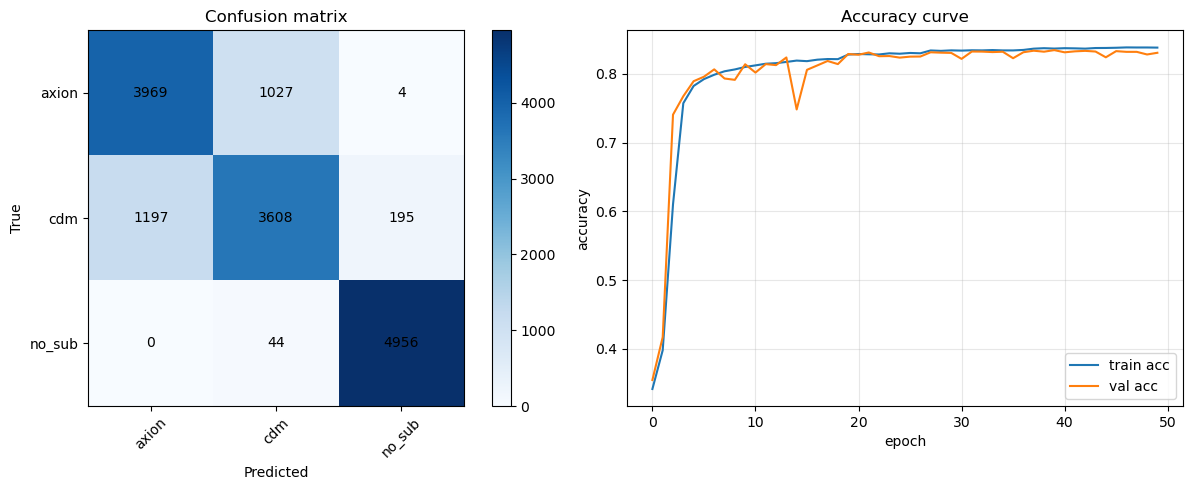

Saved metrics + figure to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/eqnn_hep_torchquantum/model_1/results


In [9]:
ckpt = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Loaded best checkpoint (val_acc={ckpt['val_acc']:.4f}, epoch={ckpt['epoch']+1}).")

all_logits, all_labels = [], []
with torch.no_grad():
    for xb, yb in tqdm(test_loader, desc="test", leave=False):
        logits = model(xb.to(device))
        all_logits.append(logits.cpu())
        all_labels.append(yb)

logits = torch.cat(all_logits).numpy()
labels = torch.cat(all_labels).numpy()
probs = torch.softmax(torch.from_numpy(logits), dim=1).numpy()
preds = probs.argmax(1)

test_acc = float((preds == labels).mean())
y_onehot = label_binarize(labels, classes=list(range(num_classes)))
try:
    macro_auc = roc_auc_score(y_onehot, probs, average="macro", multi_class="ovr")
except ValueError:
    macro_auc = float("nan")

print(f"Test accuracy:        {test_acc:.4f}")
print(f"Test macro ROC-AUC:   {macro_auc:.4f}")
print("\nClassification report:")
print(classification_report(labels, preds, target_names=class_names, digits=4))

cm = confusion_matrix(labels, preds)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
im = ax[0].imshow(cm, cmap="Blues")
ax[0].set_title("Confusion matrix")
ax[0].set_xlabel("Predicted"); ax[0].set_ylabel("True")
ax[0].set_xticks(range(num_classes)); ax[0].set_xticklabels(class_names, rotation=45)
ax[0].set_yticks(range(num_classes)); ax[0].set_yticklabels(class_names)
for i in range(num_classes):
    for j in range(num_classes):
        ax[0].text(j, i, str(cm[i, j]), ha="center", va="center")
fig.colorbar(im, ax=ax[0], fraction=0.046)

ax[1].plot(history["train_acc"], label="train acc")
ax[1].plot(history["val_acc"], label="val acc")
ax[1].set_title("Accuracy curve"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("accuracy")
ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "eqnn_hep_test_summary.png", dpi=150, bbox_inches="tight")
plt.show()

with open(RESULTS_DIR / "test_metrics.json", "w") as f:
    json.dump({"test_acc": test_acc, "macro_auc": macro_auc,
               "best_val_acc": best_val_acc, "classes": class_names}, f, indent=2)
print(f"Saved metrics + figure to {RESULTS_DIR}")

## 8. Ablation: how much does the quantum core actually contribute?

The full model is a hybrid: a learnable classical **encoder** feeds the **equivariant quantum core**
(U2/U4 filters, 256-amplitude state -> 8 `<Z>` values), then a small **head**. To isolate the quantum
core's contribution we keep the **encoder and head byte-for-byte identical** and only swap the
`256 -> 8` core. Everything else (data, loaders, epochs, optimizer, seed) is held constant, so any gap
is attributable to the core - not to capacity or training differences.

We compare three cores with the same `(B, 256) -> (B, 8)` interface:

| Variant | Core | Trainable core params | What it isolates |
|---|---|---|---|
| **Quantum (full)** | `EquivQCNN_HEP` (U2/U4 + pooling) | ~33 | the actual hybrid |
| **Fixed core** | parameter-free block-sum of amplitudes | 0 | encoder+head *alone* (lower bound) |
| **Classical core** | low-rank linear `256->r->8` | ~264 | a cheap *learnable classical* mixer |

> Note: the quantum core has only ~33 params but is a **non-linear, entangling** map, so an exact
> param-match to a classical linear map is not meaningful. The two classical references instead
> **bracket** the quantum core: a 0-param fixed reduction (below) and a small learnable linear (sideways).

In [10]:
class FixedReductionCore(nn.Module):
    """Parameter-free 256 -> 8 core: sum |amplitude|^2 over 8 contiguous blocks of 32.

    Mimics a 'measure but don't mix' baseline - it gives the head 8 numbers derived from the
    encoded state with NO learnable quantum/classical mixing. Establishes the encoder+head floor.
    """

    def __init__(self, n_out: int = 8):
        super().__init__()
        self.n_out = n_out

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        b, d = feats.shape
        blocks = feats.reshape(b, self.n_out, d // self.n_out)
        # probabilities per block, centered to roughly match the <Z> range used by the head
        return 2.0 * (blocks ** 2).sum(dim=2) - (2.0 / self.n_out)


class ClassicalCore(nn.Module):
    """Small *learnable classical* 256 -> r -> 8 mixer (low-rank, bias-free) + tanh squashing."""

    def __init__(self, n_in: int = 256, rank: int = 1, n_out: int = 8):
        super().__init__()
        self.down = nn.Linear(n_in, rank, bias=False)
        self.up = nn.Linear(rank, n_out, bias=False)

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        return torch.tanh(self.up(self.down(feats)))


class ConfigurableClassifier(nn.Module):
    """Identical front-end + head, with a swappable (B,256)->(B,8) core for the ablation.

    freeze_encoder=False: trainable learnable encoder (the original hybrid setup).
    freeze_encoder=True : NO learnable encoder at all - the 256-dim features are the deterministic,
                          noise-free antisymmetric map `equivariant_amplitude_features`. This makes
                          the CORE the only trainable mixer, so the ablation truly tests the core.
    """

    def __init__(self, core: nn.Module, enc_size=16, n_out=8, num_classes=3, freeze_encoder=False):
        super().__init__()
        self.enc_size = enc_size
        self.freeze_encoder = freeze_encoder
        self.reduce = nn.AdaptiveAvgPool2d((enc_size, enc_size))
        # Only build the learnable encoder when we actually train it.
        self.encoder = None if freeze_encoder else AmplitudeEncoder(enc_size=enc_size)
        self.core = core
        self.head = nn.Linear(n_out, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 4 and x.shape[1] > 1:
            x = x.mean(dim=1, keepdim=True)
        x = self.reduce(x).squeeze(1).clamp(0.0, 1.0)
        if self.freeze_encoder:
            feats = equivariant_amplitude_features(x)   # deterministic, 0 trainable params
        else:
            feats = self.encoder(x)                      # learnable encoder
        z = self.core(feats)               # (B, 8)   - the ONLY trainable mixer when frozen
        return self.head(z)


class QuantumCoreWrapper(nn.Module):
    """Wrap EquivQCNN_HEP as a pure (B,256)->(B,8) core (drop its internal head)."""

    def __init__(self, n_qubits=8):
        super().__init__()
        self.qcnn = EquivQCNN_HEP(n_qubits=n_qubits, num_classes=8)  # head replaced below
        self.qcnn.head = nn.Identity()  # we want the raw 8 <Z>, the outer head does the rest

    def forward(self, feats: torch.Tensor) -> torch.Tensor:
        return self.qcnn(feats)         # (B, 8) raw <Z> on all qubits


def count_trainable(module: nn.Module) -> int:
    return sum(p.numel() for p in module.parameters() if p.requires_grad)


print("Core trainable params:")
print(f"  quantum  : {count_trainable(QuantumCoreWrapper())}")
print(f"  fixed    : {count_trainable(FixedReductionCore())}")
print(f"  classical: {count_trainable(ClassicalCore(rank=1))}")

Core trainable params:
  quantum  : 33
  fixed    : 0
  classical: 264


In [11]:
def train_and_eval(make_model, tag, epochs=None, seed=42):
    """Train a model variant with the SAME loop/optimizer/data, return its test metrics.

    make_model: zero-arg callable returning a fresh model on `device`.
    Uses the globals: criterion settings, train/val/test loaders, step, weight_decay, patience,
    num_epochs, num_classes, class_names (all defined earlier in the notebook).
    """
    epochs = num_epochs if epochs is None else epochs
    torch.manual_seed(seed); np.random.seed(seed)

    m = make_model().to(device)
    crit = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(m.parameters(), lr=step, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=4)
    n_total = count_trainable(m)
    n_core = count_trainable(m.core) if hasattr(m, "core") else float("nan")

    def _epoch(loader, train_mode):
        m.train(train_mode)
        tot, corr, lsum = 0, 0, 0.0
        torch.set_grad_enabled(train_mode)
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if train_mode:
                opt.zero_grad()
            out = m(xb)
            loss = crit(out, yb)
            if train_mode:
                loss.backward(); opt.step()
            lsum += loss.item() * xb.size(0)
            corr += (out.argmax(1) == yb).sum().item()
            tot += xb.size(0)
        return lsum / tot, corr / tot

    best_val, best_state, no_imp = 0.0, None, 0
    val_curve = []
    for ep in range(epochs):
        t0 = time.time()
        tr_l, tr_a = _epoch(train_loader, True)
        va_l, va_a = _epoch(val_loader, False)
        sched.step(va_a)
        val_curve.append(va_a)
        if va_a > best_val:
            best_val, no_imp = va_a, 0
            best_state = copy.deepcopy(m.state_dict())
        else:
            no_imp += 1
        print(f"[{tag}] epoch {ep+1:02d}/{epochs} | train acc {tr_a:.4f} | "
              f"val acc {va_a:.4f} (best {best_val:.4f}) | {time.time()-t0:.1f}s")
        if no_imp >= patience:
            print(f"[{tag}] early stop at epoch {ep+1}")
            break

    if best_state is not None:
        m.load_state_dict(best_state)
    m.eval()

    logits_list, labels_list = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            logits_list.append(m(xb.to(device)).cpu()); labels_list.append(yb)
    lg = torch.cat(logits_list).numpy(); lb = torch.cat(labels_list).numpy()
    pr = torch.softmax(torch.from_numpy(lg), dim=1).numpy()
    pred = pr.argmax(1)
    acc = float((pred == lb).mean())
    yoh = label_binarize(lb, classes=list(range(num_classes)))
    try:
        auc_macro = roc_auc_score(yoh, pr, average="macro", multi_class="ovr")
    except ValueError:
        auc_macro = float("nan")
    f1m = f1_score(lb, pred, average="macro")
    print(f"[{tag}] TEST acc={acc:.4f} macroAUC={auc_macro:.4f} macroF1={f1m:.4f} "
          f"| total params={n_total} core params={n_core}")
    return {"tag": tag, "test_acc": acc, "macro_auc": auc_macro, "macro_f1": f1m,
            "best_val_acc": best_val, "total_params": n_total, "core_params": n_core,
            "val_curve": val_curve}

In [12]:
# Use a shorter budget for the ablation so the three runs are quick to compare; bump if you like.
ABLATION_EPOCHS = int(os.environ.get("DEEPLENSE_ABLATION_EPOCHS", str(min(num_epochs, 20))))
print(f"Running ablation for {ABLATION_EPOCHS} epochs per variant\n")

variants = {
    "quantum":   lambda: ConfigurableClassifier(QuantumCoreWrapper(n_qubits=N_QUBITS),
                                                enc_size=ENC_SIZE, n_out=8, num_classes=num_classes),
    "fixed":     lambda: ConfigurableClassifier(FixedReductionCore(n_out=8),
                                                enc_size=ENC_SIZE, n_out=8, num_classes=num_classes),
    "classical": lambda: ConfigurableClassifier(ClassicalCore(rank=1, n_out=8),
                                                enc_size=ENC_SIZE, n_out=8, num_classes=num_classes),
}

ablation_results = {}
for name, ctor in variants.items():
    print(f"===== Variant: {name} =====")
    ablation_results[name] = train_and_eval(ctor, tag=name, epochs=ABLATION_EPOCHS)
    print()

Running ablation for 20 epochs per variant

===== Variant: quantum =====
[quantum] epoch 01/20 | train acc 0.3398 | val acc 0.3544 (best 0.3544) | 70.2s
[quantum] epoch 02/20 | train acc 0.3868 | val acc 0.4723 (best 0.4723) | 70.5s
[quantum] epoch 03/20 | train acc 0.6889 | val acc 0.7494 (best 0.7494) | 70.3s
[quantum] epoch 04/20 | train acc 0.7686 | val acc 0.7835 (best 0.7835) | 70.6s
[quantum] epoch 05/20 | train acc 0.7861 | val acc 0.7820 (best 0.7835) | 70.1s
[quantum] epoch 06/20 | train acc 0.7935 | val acc 0.8019 (best 0.8019) | 70.6s
[quantum] epoch 07/20 | train acc 0.7988 | val acc 0.8023 (best 0.8023) | 70.6s
[quantum] epoch 08/20 | train acc 0.8018 | val acc 0.8065 (best 0.8065) | 70.5s
[quantum] epoch 09/20 | train acc 0.8042 | val acc 0.7645 (best 0.8065) | 70.4s
[quantum] epoch 10/20 | train acc 0.8079 | val acc 0.8142 (best 0.8142) | 70.4s
[quantum] epoch 11/20 | train acc 0.8100 | val acc 0.8135 (best 0.8142) | 70.4s
[quantum] epoch 12/20 | train acc 0.8115 | val 

           test_acc  macro_auc  macro_f1  best_val_acc  core_params  total_params
variant                                                                          
quantum      0.8187     0.9257    0.8155        0.8198           33          2686
fixed        0.8179     0.9230    0.8153        0.8206            0          2653
classical    0.8183     0.9177    0.8156        0.8200          264          2917

Quantum core lift over fixed (encoder+head floor): +0.07 pts
Quantum core vs small learnable classical mixer:    +0.04 pts


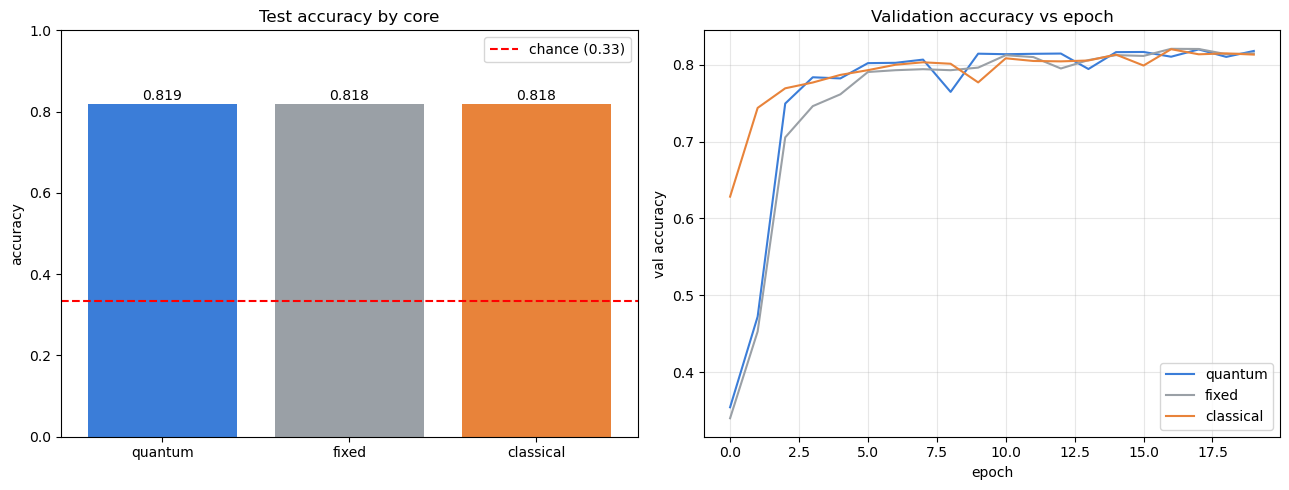


Saved ablation summary + figure to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/eqnn_hep_torchquantum/model_1/results


In [13]:
import pandas as pd

rows = []
for name in ("quantum", "fixed", "classical"):
    r = ablation_results[name]
    rows.append({"variant": name, "test_acc": r["test_acc"], "macro_auc": r["macro_auc"],
                 "macro_f1": r["macro_f1"], "best_val_acc": r["best_val_acc"],
                 "core_params": r["core_params"], "total_params": r["total_params"]})
df = pd.DataFrame(rows).set_index("variant")
print(df.round(4).to_string())

q = ablation_results["quantum"]["test_acc"]
fx = ablation_results["fixed"]["test_acc"]
cl = ablation_results["classical"]["test_acc"]
print(f"\nQuantum core lift over fixed (encoder+head floor): {100*(q-fx):+.2f} pts")
print(f"Quantum core vs small learnable classical mixer:    {100*(q-cl):+.2f} pts")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
names = ["quantum", "fixed", "classical"]
accs = [ablation_results[n]["test_acc"] for n in names]
aucs = [ablation_results[n]["macro_auc"] for n in names]
colors = ["#3b7dd8", "#9aa0a6", "#e8833a"]
bars = ax[0].bar(names, accs, color=colors)
ax[0].axhline(1.0 / num_classes, ls="--", c="red", label=f"chance ({1/num_classes:.2f})")
ax[0].set_title("Test accuracy by core"); ax[0].set_ylabel("accuracy"); ax[0].set_ylim(0, 1)
for b, a in zip(bars, accs):
    ax[0].text(b.get_x() + b.get_width() / 2, a + 0.01, f"{a:.3f}", ha="center")
ax[0].legend()

for n, c in zip(names, colors):
    ax[1].plot(ablation_results[n]["val_curve"], label=n, color=c)
ax[1].set_title("Validation accuracy vs epoch"); ax[1].set_xlabel("epoch")
ax[1].set_ylabel("val accuracy"); ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ablation_quantum_contribution.png", dpi=150, bbox_inches="tight")
plt.show()

with open(RESULTS_DIR / "ablation_results.json", "w") as f:
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != "val_curve"}
               for k, v in ablation_results.items()}, f, indent=2)
print(f"\nSaved ablation summary + figure to {RESULTS_DIR}")

## 9. Frozen-encoder ablation: give the quantum core a real job

Section 8 showed the quantum core adds ~0 lift - because the **learnable encoder already separates the
classes**, so the core (quantum, classical, or even a 0-param reduction) is irrelevant downstream.

Here we remove that confound: we **freeze the front-end** to the deterministic, noise-free
`equivariant_amplitude_features` map (0 trainable params), so the **core is the only trainable mixer**.
Now the comparison genuinely measures *which core extracts the most class signal from identical fixed
features* - i.e., does the equivariant quantum circuit actually help?

Same three cores, same training budget, same seed; the only change is `freeze_encoder=True`.

> Interpretation guide:
> - **quantum >> fixed and >= classical** -> the equivariant quantum mixing is doing real work.
> - **quantum ~ classical > fixed** -> a learnable mixer helps, but quantum is not special.
> - **all ~ equal** -> the fixed features are the ceiling; mixing (quantum or classical) adds little.

In [14]:
print(f"Running FROZEN-encoder ablation for {ABLATION_EPOCHS} epochs per variant")
print("Front-end = fixed equivariant_amplitude_features (0 trainable params)\n")

frozen_variants = {
    "quantum":   lambda: ConfigurableClassifier(QuantumCoreWrapper(n_qubits=N_QUBITS),
                                                enc_size=ENC_SIZE, n_out=8, num_classes=num_classes,
                                                freeze_encoder=True),
    "fixed":     lambda: ConfigurableClassifier(FixedReductionCore(n_out=8),
                                                enc_size=ENC_SIZE, n_out=8, num_classes=num_classes,
                                                freeze_encoder=True),
    "classical": lambda: ConfigurableClassifier(ClassicalCore(rank=1, n_out=8),
                                                enc_size=ENC_SIZE, n_out=8, num_classes=num_classes,
                                                freeze_encoder=True),
}

frozen_results = {}
for name, ctor in frozen_variants.items():
    print(f"===== Frozen-encoder variant: {name} =====")
    frozen_results[name] = train_and_eval(ctor, tag=f"frozen-{name}", epochs=ABLATION_EPOCHS)
    print()

Running FROZEN-encoder ablation for 20 epochs per variant
Front-end = fixed equivariant_amplitude_features (0 trainable params)

===== Frozen-encoder variant: quantum =====
[frozen-quantum] epoch 01/20 | train acc 0.3469 | val acc 0.3721 (best 0.3721) | 69.2s
[frozen-quantum] epoch 02/20 | train acc 0.5022 | val acc 0.5615 (best 0.5615) | 69.5s
[frozen-quantum] epoch 03/20 | train acc 0.6065 | val acc 0.6513 (best 0.6513) | 69.3s
[frozen-quantum] epoch 04/20 | train acc 0.6291 | val acc 0.5760 (best 0.6513) | 69.4s
[frozen-quantum] epoch 05/20 | train acc 0.6407 | val acc 0.6513 (best 0.6513) | 69.3s
[frozen-quantum] epoch 06/20 | train acc 0.6517 | val acc 0.6663 (best 0.6663) | 69.9s
[frozen-quantum] epoch 07/20 | train acc 0.6593 | val acc 0.6676 (best 0.6676) | 69.6s
[frozen-quantum] epoch 08/20 | train acc 0.6675 | val acc 0.6351 (best 0.6676) | 69.8s
[frozen-quantum] epoch 09/20 | train acc 0.6719 | val acc 0.6753 (best 0.6753) | 69.7s
[frozen-quantum] epoch 10/20 | train acc 0.6

                  test_acc  macro_auc  macro_f1  best_val_acc  core_params  total_params
variant                                                                                 
frozen-quantum      0.6972     0.8536    0.6872        0.6916           33            60
frozen-fixed        0.3941     0.5601    0.3734        0.4001            0            27
frozen-classical    0.7499     0.8853    0.7461        0.7495          264           291

[FROZEN] Quantum core lift over fixed reduction: +30.31 pts
[FROZEN] Quantum core vs learnable classical mixer: -5.27 pts
-> A learnable mixer helps a LOT over the fixed floor (+35.6 pts best).
   The quantum core helps substantially, but a cheap classical mixer helps more.
   (Quantum core genuinely contributes: +30.3 pts over doing nothing.)


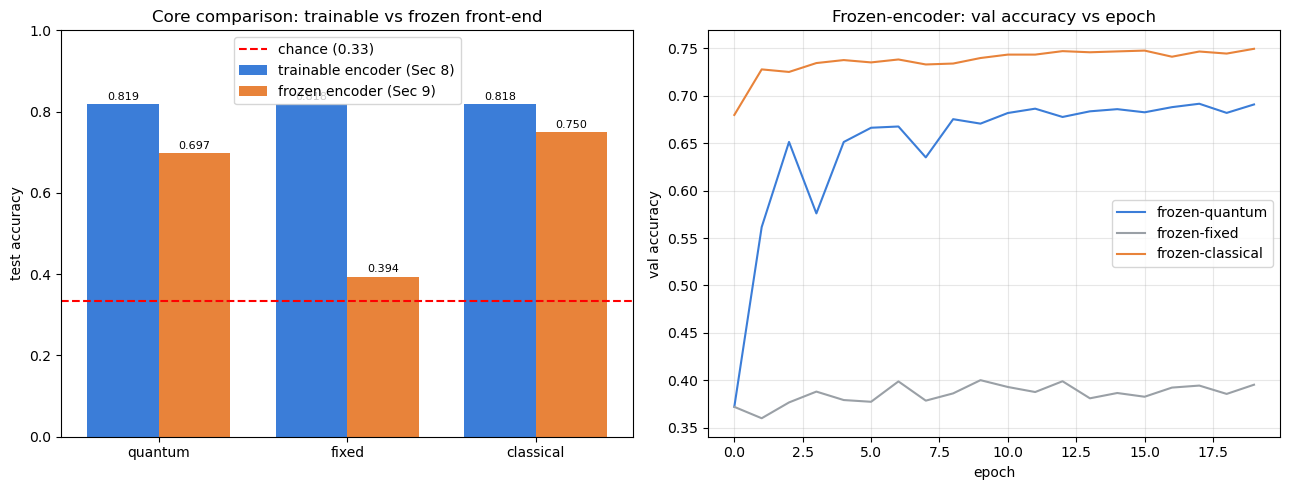


Saved frozen-encoder ablation summary + figure to /home/jovyan/ssh-test-datavol-1/deeplense-quantum/notebooks/equivariant/eqnn_hep_torchquantum/model_1/results


In [15]:
rows = []
for name in ("quantum", "fixed", "classical"):
    r = frozen_results[name]
    rows.append({"variant": f"frozen-{name}", "test_acc": r["test_acc"], "macro_auc": r["macro_auc"],
                 "macro_f1": r["macro_f1"], "best_val_acc": r["best_val_acc"],
                 "core_params": r["core_params"], "total_params": r["total_params"]})
df_frozen = pd.DataFrame(rows).set_index("variant")
print(df_frozen.round(4).to_string())

q = frozen_results["quantum"]["test_acc"]
fx = frozen_results["fixed"]["test_acc"]
cl = frozen_results["classical"]["test_acc"]
print(f"\n[FROZEN] Quantum core lift over fixed reduction: {100*(q-fx):+.2f} pts")
print(f"[FROZEN] Quantum core vs learnable classical mixer: {100*(q-cl):+.2f} pts")
TOL = 0.01
best_mix = max(q, cl)
mixing_helps = (best_mix - fx) > TOL          # does ANY learnable mixer beat the fixed floor?
q_beats_fx = (q - fx) > TOL                    # does the quantum core beat the fixed floor?
if not mixing_helps:
    print("-> Fixed features are the ceiling here; neither quantum nor classical mixing helps.")
else:
    print(f"-> A learnable mixer helps a LOT over the fixed floor (+{100*(best_mix-fx):.1f} pts best).")
    if q - cl > TOL:
        print("   The equivariant QUANTUM core is the strongest mixer.")
    elif abs(q - cl) <= TOL:
        print("   Quantum and classical mixers are comparable.")
    else:
        print("   The quantum core helps substantially, but a cheap classical mixer helps more.")
    if q_beats_fx:
        print(f"   (Quantum core genuinely contributes: +{100*(q-fx):.1f} pts over doing nothing.)")

# Side-by-side: trainable-encoder (Sec 8) vs frozen-encoder (Sec 9)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
names = ["quantum", "fixed", "classical"]
x = np.arange(len(names)); w = 0.38
train_accs = [ablation_results[n]["test_acc"] for n in names]
frozen_accs = [frozen_results[n]["test_acc"] for n in names]
ax[0].bar(x - w/2, train_accs, w, label="trainable encoder (Sec 8)", color="#3b7dd8")
ax[0].bar(x + w/2, frozen_accs, w, label="frozen encoder (Sec 9)", color="#e8833a")
ax[0].axhline(1.0 / num_classes, ls="--", c="red", label=f"chance ({1/num_classes:.2f})")
ax[0].set_xticks(x); ax[0].set_xticklabels(names); ax[0].set_ylim(0, 1)
ax[0].set_ylabel("test accuracy"); ax[0].set_title("Core comparison: trainable vs frozen front-end")
ax[0].legend()
for xi, (ta, fa) in enumerate(zip(train_accs, frozen_accs)):
    ax[0].text(xi - w/2, ta + 0.01, f"{ta:.3f}", ha="center", fontsize=8)
    ax[0].text(xi + w/2, fa + 0.01, f"{fa:.3f}", ha="center", fontsize=8)

colors = ["#3b7dd8", "#9aa0a6", "#e8833a"]
for n, c in zip(names, colors):
    ax[1].plot(frozen_results[n]["val_curve"], label=f"frozen-{n}", color=c)
ax[1].set_title("Frozen-encoder: val accuracy vs epoch"); ax[1].set_xlabel("epoch")
ax[1].set_ylabel("val accuracy"); ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "ablation_frozen_encoder.png", dpi=150, bbox_inches="tight")
plt.show()

with open(RESULTS_DIR / "ablation_frozen_results.json", "w") as f:
    json.dump({k: {kk: vv for kk, vv in v.items() if kk != "val_curve"}
               for k, v in frozen_results.items()}, f, indent=2)
print(f"\nSaved frozen-encoder ablation summary + figure to {RESULTS_DIR}")